# Mol Visualization

Original molecule (SMILES): CCCCCCCCOCC
Modified molecule (SMILES): C.C.C.C.CC


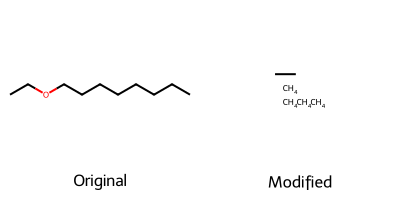

In [149]:
import random
from rdkit import Chem
from rdkit.Chem import Draw

def remove_atoms(mol, num_atoms_to_remove): 
    assert num_atoms_to_remove < mol.GetNumAtoms(), "num_atoms_to_remove should be less than the number of atoms in the molecule."
    assert num_atoms_to_remove > 0, "num_atoms_to_remove should be positive."

    rw_mol = Chem.RWMol(mol)
    
    while num_atoms_to_remove > 0:
        atom_indices = list(range(rw_mol.GetNumAtoms()))
        atom_index = random.choice(atom_indices)
        rw_mol.RemoveAtom(atom_index)
        num_atoms_to_remove -= 1

    out_mol = rw_mol.GetMol()
    Chem.SanitizeMol(out_mol)
    return out_mol

# Example usage
smiles = 'CCOCCCCCCCC'  # Ethoxyethane (diethyl ether)
mol = Chem.MolFromSmiles(smiles)
print("Original molecule (SMILES):", Chem.MolToSmiles(mol))

# Remove 2 random atoms
modified_mol = remove_atoms(mol, 5)
print("Modified molecule (SMILES):", Chem.MolToSmiles(modified_mol))

# Visualize molecules
Draw.MolsToGridImage([mol, modified_mol], molsPerRow=2, subImgSize=(200, 200),
                     legends=['Original', 'Modified'])

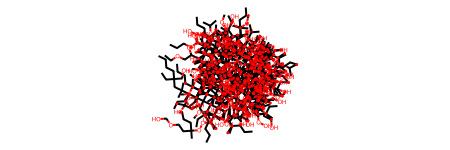

In [136]:
def add_atom_via_implicit_valence(mol, necessary_change):
    assert necessary_change > 0, "necessary_change should be positive."

    rw_mol = Chem.RWMol(mol)
    atom_counts = get_unique_atoms_and_counts(rw_mol)

    while necessary_change > 0:

        implicit_valence_ids = []
        for atom in rw_mol.GetAtoms():
            if atom.GetImplicitValence() > 0:
                implicit_valence_ids.append(atom.GetIdx())

        if not implicit_valence_ids:
            break
        connect_to_index = random.choice(implicit_valence_ids)
        
        sampled_atom = sample_atom(atom_counts)
        new_atom = Chem.Atom(sampled_atom)
        rw_mol.AddAtom(new_atom)
        rw_mol.AddBond(connect_to_index, rw_mol.GetNumAtoms() - 1, order=Chem.rdchem.BondType.SINGLE)
        necessary_change -= 1

    Chem.SanitizeMol(rw_mol.GetMol())
    return rw_mol.GetMol()



from collections import Counter
def get_unique_atoms_and_counts(molecule):
    """
    Get a list of unique atoms and their counts in the given RDKit molecule object.

    Args:
    molecule (rdkit.Chem.Mol): RDKit molecule object.

    Returns:
    dict: A dictionary with atom symbols as keys and their counts as values.
    """
    # Extract atom symbols from the molecule
    atom_symbols = [atom.GetSymbol() for atom in molecule.GetAtoms()]
    
    # Count occurrences of each atom symbol
    atom_counts = Counter(atom_symbols)
    
    return dict(atom_counts)

def sample_atom(atom_counts):
    """
    Sample an atom from the atom_counts with a probability proportional to its count.

    Args:
    atom_counts (dict): Dictionary of atom symbols and their counts.

    Returns:
    str: A sampled atom symbol based on its relative abundance.
    """
    # Extract atoms and their respective counts
    atoms = list(atom_counts.keys())
    counts = list(atom_counts.values())
    
    # Sample one atom based on the counts as weights
    sampled_atom = random.choices(atoms, weights=counts, k=1)[0]
    
    return sampled_atom

import random
from rdkit import Chem
from rdkit.Chem import rdmolops
import numpy as np

smiles = 'CCOCC'  # Ethoxyethane (diethyl ether)
mol = Chem.MolFromSmiles(smiles)

valence_dict = {
    'H': 1, 'He': 0,
    'B': 3, 'C': 4, 'N': 3, 'O': 2, 'F': 1,
    'Si': 4, 'P': 3, 'S': 2, 'Cl': 1,
    'As': 3, 'Se': 2, 'Br': 1, 'Te': 2, 'I': 1,
    # Transition metals and other elements can be added here
}

necessary_change = 1000

rw_mol = Chem.RWMol(mol)
atom_counts = get_unique_atoms_and_counts(rw_mol)

while necessary_change > 0:

    potential_bond_indices = []
    for atom in rw_mol.GetAtoms():
        if atom.GetSymbol() not in valence_dict:
            continue
        if atom.GetDegree() < valence_dict[atom.GetSymbol()]:
            potential_bond_indices.append(atom.GetIdx())

    if not potential_bond_indices:
        break

    sampled_atom = sample_atom(atom_counts)
    new_atom = Chem.Atom(sampled_atom)
    new_atom_idx = rw_mol.AddAtom(new_atom)

    connect_to_index = random.choice(potential_bond_indices)

    rw_mol.AddBond(connect_to_index, new_atom_idx, order=Chem.rdchem.BondType.SINGLE)
    necessary_change -= 1

    Chem.SanitizeMol(rw_mol.GetMol())
rw_mol.GetMol()



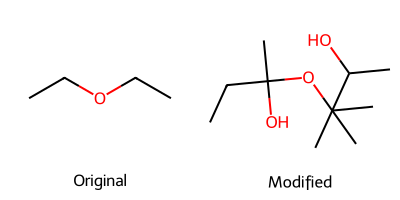

In [114]:
Draw.MolsToGridImage([mol, rw_mol.GetMol()], molsPerRow=2, subImgSize=(200, 200),
                    legends=['Original', 'Modified'])

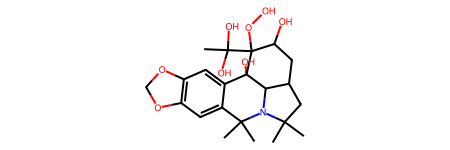

In [163]:
temp_smiles = 'CC1(C)CC2CC(O)C(OO)(C(C)(O)O)C3(O)c4cc5c(cc4C(C)(C)N1C23)OCO5'
temp_mol = Chem.MolFromSmiles(temp_smiles)
temp_mol

In [159]:
atoms = list(temp_mol.GetAtoms())
atoms[8].GetDegree()

3

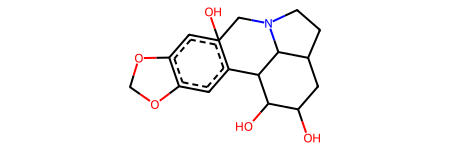

In [162]:
rw_mol = Chem.RWMol(temp_mol)
new_atom = Chem.Atom('O')
new_atom_idx = rw_mol.AddAtom(new_atom)
rw_mol.AddBond(8, new_atom_idx, order=Chem.rdchem.BondType.SINGLE)
rw_mol

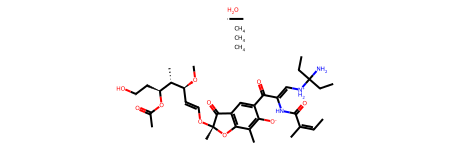

In [164]:
Chem.MolFromSmiles('C.C.C.C/C=C(/C)C(=O)NC(=C[NH2+]C(N)(CC)CC)C(=O)c1cc2c(c(C)c1[O-])O[C@](C)(O/C=C/[C@H](OC)[C@@H](C)[C@H]([CH][CH]O)OC(C)=O)C2=O.O.[CH]C')

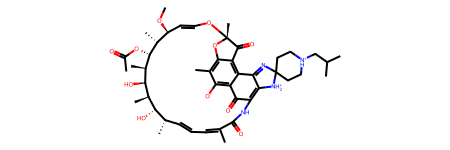

In [165]:
Chem.MolFromSmiles('CO[C@H]1/C=C/O[C@@]2(C)Oc3c(C)c([O-])c4c(c3C2=O)C2=NC3(CC[NH+](CC(C)C)CC3)[NH2+]C2=C(NC(=O)/C(C)=C\\C=C\\[C@H](C)[C@H](O)[C@@H](C)[C@@H](O)[C@@H](C)[C@H](OC(C)=O)[C@@H]1C)C4=O')

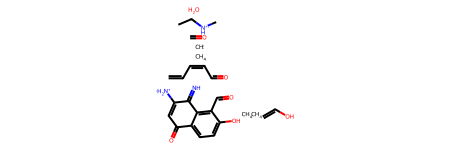

In [ ]:
Chem.MolFromSmiles('C.C.C.C=C/C=C\\C=O.C=CO.C=O.CC[NH+]C.N=C1C([NH2+])=CC(=O)c2ccc(O)c(C=O)c21.O.[CH]')

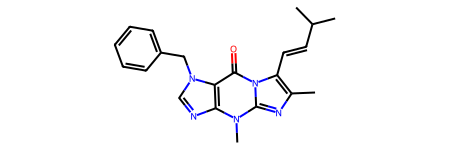

In [167]:
Chem.MolFromSmiles('Cc1nc2n(C)c3ncn(Cc4ccccc4)c3c(=O)n2c1C=CC(C)C')

In [168]:
Chem.MolFromSmiles('CC(C)C=Cc1c(C)nc2nc3ncn(Cc4ccccc4)c3c(=O)n12')

[07:35:41] Can't kekulize mol.  Unkekulized atoms: 5 6 8 9 10 11 12 13 22
